# 02. MNIST линейной моделью: softmax, перекрестная энтропия, ручные градиенты

**Задача.** Дана картинка 28x28 в оттенках серого - рукописная цифра.
Нужно определить, какая это цифра из 0..9. Это классификация на 10 классов.

**Модель этого ноутбука.** Самая простая из возможных: один линейный слой

$$z = xW + b, \qquad x \in \mathbb{R}^{B \times 784},\ W \in \mathbb{R}^{784 \times 10},\ b \in \mathbb{R}^{10}$$

Обучаемых параметров: $784 \cdot 10 + 10 = 7850$. Это называется
softmax-регрессией (или многоклассовой логистической регрессией) и формально
это нейросеть без скрытых слоев.

**Что делаем:**

1. загружаем данные и смотрим на них;
2. разбираем softmax и его численную устойчивость;
3. разбираем перекрестную энтропию как функцию потерь;
4. **выводим градиенты на бумаге** и проверяем их против autograd и против
   численной разности;
5. пишем цикл обучения вручную (без `torch.optim`) и обучаем модель;
6. смотрим, чему она научилась, и где у нее потолок.

Из `torch` используются только тензорные операции: `@`, `+`, `exp`, `log`,
`max`, `sum`, индексация. Ни `torch.nn`, ни `torch.optim`.

In [1]:
import math

import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
GEN = torch.Generator().manual_seed(0)   # отдельный генератор для воспроизводимости

print("torch", torch.__version__)

torch 2.14.1


---
## 1. Данные

Берем тот же архив, что в ноутбуке преподавателя: `mnist.pkl.gz` из
репозитория туториалов PyTorch. Внутри - готовый pickle с тремя наборами.

Почему не `torchvision.datasets.MNIST`: тот путь тянет лишнюю зависимость и
прячет данные за слоем `Dataset`/`DataLoader`. Нам нужно видеть сырой тензор
формы `(N, 784)` - на нем вся арифметика очевидна.

**Зачем нужна отдельная валидационная выборка.** Точность на обучающих данных
ничего не говорит о качестве модели: модель могла просто запомнить ответы.
Честная оценка - только на данных, которых модель не видела при обучении.
Поэтому train (50000) идет в обучение, valid (10000) - только в измерение.

In [2]:
from pathlib import Path
import gc
import gzip
import pickle
import requests

DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"
PATH.mkdir(parents=True, exist_ok=True)

URL = "https://github.com/pytorch/tutorials/raw/main/_static/"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
    print("скачиваем", FILENAME, "...")
    content = requests.get(URL + FILENAME, timeout=60).content
    (PATH / FILENAME).open("wb").write(content)

with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
    (x_train, y_train), (x_valid, y_valid), _ = pickle.load(f, encoding="latin-1")

print("загружено из", PATH / FILENAME)

загружено из data/mnist/mnist.pkl.gz


Переводим numpy-массивы в тензоры PyTorch.

Важная деталь про типы: признаки `x` должны быть `float32` (с ними идет
арифметика), а метки `y` - **`int64`** (`long`). PyTorch требует именно `int64`
для индексации по классам. Если оставить `float`, индексация в функции потерь
упадет с ошибкой типа.

In [3]:
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.int64)
x_valid = torch.tensor(x_valid, dtype=torch.float32)
y_valid = torch.tensor(y_valid, dtype=torch.int64)

# Третий набор (test, 10000 примеров) в проекте не используется - освобождаем.
# Без этого он остается в памяти до конца сессии: распаковка кортежа создает
# на него ссылку, и сборщик мусора его не тронет.
del _
gc.collect()

n, d = x_train.shape
num_classes = 10

print(f"x_train: {tuple(x_train.shape)}  {x_train.dtype}  "
      f"значения в [{x_train.min():.3f}; {x_train.max():.3f}]")
print(f"y_train: {tuple(y_train.shape)}  {y_train.dtype}  "
      f"классы {int(y_train.min())}..{int(y_train.max())}")
print(f"x_valid: {tuple(x_valid.shape)}")
print(f"\nпримеров для обучения n = {n}, признаков d = {d} (= 28*28 = {28*28})")

# Сколько памяти занимают данные. Полезно знать: x_train - самый крупный
# объект в сессии, и именно он создает проблемы инспектору переменных в IDE.
for name, t in [("x_train", x_train), ("x_valid", x_valid)]:
    print(f"{name}: {t.numel() * t.element_size() / 1024 / 1024:.0f} МБ")

x_train: (50000, 784)  torch.float32  значения в [0.000; 0.996]
y_train: (50000,)  torch.int64  классы 0..9
x_valid: (10000, 784)

примеров для обучения n = 50000, признаков d = 784 (= 28*28 = 784)
x_train: 150 МБ
x_valid: 30 МБ


Данные уже нормированы в диапазон $[0, 1]$: в исходном формате пиксель -
это целое 0..255, здесь он поделен на 255.

**Почему нормировка обязательна.** Логит $z_k = \sum_i x_i W_{ik}$ - сумма
784 слагаемых. Если $x_i$ будут порядка 255, логиты окажутся порядка сотен,
`exp` в softmax получит гигантский аргумент, и обучение развалится на первом
же шаге. С $x_i \in [0,1]$ логиты остаются в разумных пределах.

Картинка в архиве уже **развернута в вектор** длины 784: строки 28x28
положены одна за другой. Для линейной модели это не потеря - она все равно
не знает про соседство пикселей. (А вот сверточная сеть на развернутом
векторе работать уже не сможет, ей нужна двумерная структура.)

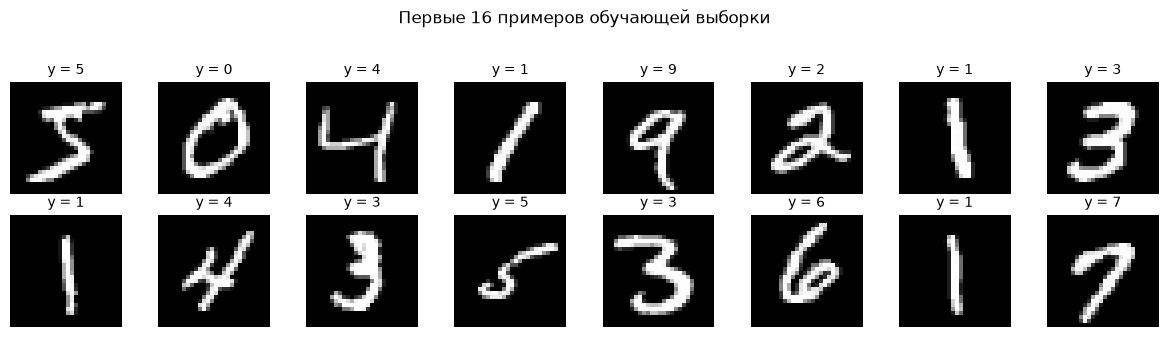

примеров каждого класса в train:
  0:  4932  (9.9%)
  1:  5678  (11.4%)
  2:  4968  (9.9%)
  3:  5101  (10.2%)
  4:  4859  (9.7%)
  5:  4506  (9.0%)
  6:  4951  (9.9%)
  7:  5175  (10.3%)
  8:  4842  (9.7%)
  9:  4988  (10.0%)


In [4]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, idx in zip(axes.ravel(), range(16)):
    ax.imshow(x_train[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"y = {y_train[idx].item()}", fontsize=10)
    ax.axis("off")
fig.suptitle("Первые 16 примеров обучающей выборки", y=1.04)
plt.tight_layout()
plt.show()

# Распределение классов: важно убедиться, что оно примерно равномерное.
# Если бы один класс составлял 90% данных, модель могла бы выдать 90%
# точности, вообще ничего не выучив.
counts = torch.bincount(y_train, minlength=10)
print("примеров каждого класса в train:")
for k in range(10):
    print(f"  {k}: {counts[k].item():>5}  ({counts[k].item() / n * 100:.1f}%)")

---
## 2. Инициализация параметров

$$W \sim \frac{\mathcal{N}(0, 1)}{\sqrt{784}}, \qquad b = 0$$

**Почему именно деление на $\sqrt{784}$** (это упрощенная инициализация Ксавье,
ровно та же, что в ноутбуке преподавателя).

Логит $z_k = \sum_{i=1}^{784} x_i W_{ik}$ - сумма 784 слагаемых. Для
независимых случайных слагаемых дисперсия суммы равна сумме дисперсий, то есть
растет пропорционально числу слагаемых $d$, а стандартное отклонение - как
$\sqrt{d}$. Если взять $W \sim \mathcal{N}(0,1)$ без масштабирования, логиты
получатся с разбросом около $\sqrt{784} = 28$.

Чем это плохо: softmax от логитов с разбросом 28 выдает почти ноль для девяти
классов и почти единицу для одного - то есть модель с самого начала
"уверена" в случайном ответе. А градиент перекрестной энтропии равен
$p - y$, и при $p$ почти на границе 0 или 1 он почти нулевой. Обучение
встанет. Делением на $\sqrt{d}$ мы возвращаем разброс логитов к порядку 1.

**Смещения с нуля:** асимметрию по классам модель доберет сама, случайный
сдвиг тут ничего не дает.

`requires_grad_()` помечает тензор как обучаемый параметр - с этого момента
PyTorch записывает все операции с ним в граф.

In [5]:
weights = torch.randn(d, num_classes, generator=GEN) / math.sqrt(d)
bias = torch.zeros(num_classes)

weights.requires_grad_()
bias.requires_grad_()

print("weights:", tuple(weights.shape), " bias:", tuple(bias.shape))
print("всего параметров:", weights.numel() + bias.numel())

# Проверим рассуждение про масштаб экспериментально
z_scaled = x_train[:1000] @ weights + bias
w_bad = torch.randn(d, num_classes, generator=torch.Generator().manual_seed(1))
z_unscaled = x_train[:1000] @ w_bad

print(f"\nразброс логитов с делением на sqrt(d): std = {z_scaled.std():.3f}")
print(f"разброс логитов без деления:           std = {z_unscaled.std():.3f}")

weights: (784, 10)  bias: (10,)
всего параметров: 7850

разброс логитов с делением на sqrt(d): std = 0.389
разброс логитов без деления:           std = 9.235


---
## 3. Softmax: из логитов в вероятности

Модель выдает 10 чисел-логитов $z_k$, которые могут быть любыми - в том числе
отрицательными и не дающими в сумме единицу. Чтобы получить распределение
вероятностей по классам, применяют softmax:

$$p_k = \mathrm{softmax}(z)_k = \frac{e^{z_k}}{\sum_{j=1}^{10} e^{z_j}}$$

Свойства, которые делают его правильным выбором:

* $p_k > 0$ для всех $k$ (экспонента положительна);
* $\sum_k p_k = 1$ по построению;
* монотонность: больший логит дает большую вероятность, **порядок классов
  не меняется**. Из этого важное следствие: для предсказания softmax не нужен -
  `argmax` от логитов и от вероятностей дает один и тот же класс.

### Численная устойчивость: почему вычитают максимум

Softmax не меняется, если из всех логитов вычесть одно и то же число $m$:

$$\frac{e^{z_k - m}}{\sum_j e^{z_j - m}} = \frac{e^{-m} e^{z_k}}{e^{-m}\sum_j e^{z_j}} = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

Множитель $e^{-m}$ сокращается. Математически вычитание бесполезно, численно -
критично: в `float32` уже $e^{89}$ дает `inf`. Берут $m = \max_j z_j$, тогда
наибольший показатель равен $e^0 = 1$, и переполнения не бывает никогда.

In [6]:
def softmax(z):
    # softmax по последней оси, с вычитанием максимума строки.
    # keepdim=True оставляет ось размером 1, чтобы broadcasting вычел
    # максимум строки из всех элементов этой строки.
    z_shifted = z - z.max(dim=-1, keepdim=True).values
    exp_z = z_shifted.exp()
    return exp_z / exp_z.sum(dim=-1, keepdim=True)


# Демонстрация переполнения
z_big = torch.tensor([[1000.0, 999.0, 998.0]])

naive = z_big.exp() / z_big.exp().sum(dim=-1, keepdim=True)
stable = softmax(z_big)

print("наивный softmax (без вычитания max):", naive)
print("устойчивый softmax:                 ", stable)
print("\nexp(1000) в float32 =", torch.tensor(1000.0).exp().item())
print("inf / inf = nan - отсюда NaN в наивной версии")

наивный softmax (без вычитания max): tensor([[nan, nan, nan]])
устойчивый softmax:                  tensor([[0.6652, 0.2447, 0.0900]])

exp(1000) в float32 = inf
inf / inf = nan - отсюда NaN в наивной версии


---
## 4. Функция потерь: перекрестная энтропия

Нужна одна **скалярная** величина, которую можно минимизировать. Берем
отрицательный логарифм правдоподобия (negative log-likelihood):

$$L = -\frac{1}{B}\sum_{n=1}^{B} \log p_{n, y_n}$$

Здесь $p_{n, y_n}$ - вероятность, которую модель дала **правильному** классу
$n$-го примера. Логика:

* модель угадала уверенно, $p_{y} \to 1$, значит $-\log p_y \to 0$ - штрафа нет;
* модель ошиблась уверенно, $p_y \to 0$, значит $-\log p_y \to +\infty$ -
  штраф неограниченный.

**Почему логарифм, а не, скажем, $1 - p_y$.** Во-первых, логарифм превращает
произведение вероятностей независимых примеров в сумму - отсюда и название
"правдоподобие". Во-вторых, он дает бесконечный штраф за уверенную ошибку,
и это сильно ускоряет обучение. В-третьих (и это главное на практике),
в паре с softmax он дает исключительно простой градиент - увидим в разделе 5.

**Почему среднее, а не сумма.** Тогда масштаб ошибки и градиента не зависит
от размера батча, и шаг обучения `lr` не надо подбирать заново при смене
`batch_size`.

### log_softmax вместо log(softmax(z))

Считать `softmax(z).log()` плохо: при очень маленьком $p_k$ получается
`log(0) = -inf`, и дальше `NaN` в градиенте. Устойчивая форма:

$$\log p_k = z_k - \log\sum_j e^{z_j} = (z_k - m) - \log\sum_j e^{z_j - m}$$

Здесь логарифм берется от суммы, которая **не меньше 1** (слагаемое с
$j = \arg\max$ дает ровно $e^0 = 1$), поэтому `-inf` не возникает.

In [7]:
def log_softmax(z):
    # log(softmax(z)), посчитанный устойчиво, без промежуточного softmax
    m = z.max(dim=-1, keepdim=True).values
    z_shifted = z - m
    return z_shifted - z_shifted.exp().sum(dim=-1, keepdim=True).log()


def log_softmax_naive(z):
    # Версия из ноутбука преподавателя: без вычитания максимума.
    # Оставлена специально для сравнения.
    return z - z.exp().sum(dim=-1, keepdim=True).log()


def nll(log_probs, y):
    # Negative log-likelihood по уже прологарифмированным вероятностям.
    #
    # log_probs[range(B), y] - продвинутая индексация: из каждой строки n
    # берется ровно один элемент, номер которого задан меткой y[n].
    # Результат - вектор длины B, а не матрица.
    batch_size = y.shape[0]
    return -log_probs[range(batch_size), y].mean()


def cross_entropy(z, y):
    # Перекрестная энтропия прямо от логитов
    return nll(log_softmax(z), y)


# Сравнение устойчивой и наивной версий
z_small = torch.tensor([[1.0, 2.0, 3.0]])
z_huge = torch.tensor([[1000.0, 999.0, 998.0]])

print("на логитах порядка 1 обе версии совпадают:")
print("  устойчивая:", log_softmax(z_small))
print("  наивная:   ", log_softmax_naive(z_small))
print("\nна логитах порядка 1000 наивная ломается:")
print("  устойчивая:", log_softmax(z_huge))
print("  наивная:   ", log_softmax_naive(z_huge))

на логитах порядка 1 обе версии совпадают:
  устойчивая: tensor([[-2.4076, -1.4076, -0.4076]])
  наивная:    tensor([[-2.4076, -1.4076, -0.4076]])

на логитах порядка 1000 наивная ломается:
  устойчивая: tensor([[-0.4076, -1.4076, -2.4076]])
  наивная:    tensor([[-inf, -inf, -inf]])


### Первый прямой проход

Прогоним один мини-батч через необученную модель. Ожидаемое значение ошибки
известно заранее: случайная модель дает каждому классу вероятность $1/10$,
значит

$$L \approx -\log \frac{1}{10} = \log 10 \approx 2.303$$

Эта прикидка - полезнейший прием отладки. Если на старте ошибка не около
2.3, а, скажем, 15, значит что-то не так с инициализацией или с нормировкой
данных, и дальше запускать обучение бессмысленно.

In [8]:
bs = 64   # размер мини-батча

xb = x_train[0:bs]
yb = y_train[0:bs]

z = xb @ weights + bias             # логиты, форма (64, 10)
log_p = log_softmax(z)              # лог-вероятности
p = softmax(z)                      # вероятности
loss = nll(log_p, yb)

print("формы:  xb", tuple(xb.shape), " -> z", tuple(z.shape))
print(f"\nсумма вероятностей первой строки: {p[0].sum():.6f} (должна быть 1.0)")
print("вероятности первого примера:", [round(v, 3) for v in p[0].tolist()])
print(f"правильный класс: {yb[0].item()}, модель дала ему p = {p[0, yb[0]]:.3f}")
print(f"\nошибка на батче:    {loss.item():.4f}")
print(f"ожидание log(10) =  {math.log(10):.4f}")

формы:  xb (64, 784)  -> z (64, 10)

сумма вероятностей первой строки: 1.000000 (должна быть 1.0)
вероятности первого примера: [0.054, 0.05, 0.095, 0.063, 0.124, 0.176, 0.111, 0.134, 0.09, 0.104]
правильный класс: 5, модель дала ему p = 0.176

ошибка на батче:    2.4608
ожидание log(10) =  2.3026


In [9]:
def accuracy(z, y):
    # Доля правильных ответов.
    # argmax по логитам дает тот же класс, что argmax по softmax:
    # softmax монотонен и порядок не меняет, поэтому softmax тут не нужен.
    preds = torch.argmax(z, dim=1)
    return (preds == y).to(torch.float32).mean()


print("предсказания:", torch.argmax(z, dim=1)[:20].tolist())
print("правильные:  ", yb[:20].tolist())
print(f"\nточность необученной модели на батче: {accuracy(z, yb).item() * 100:.1f}%")
print("(ожидаем около 10% - это случайное угадывание из 10 классов)")

предсказания: [5, 5, 1, 6, 5, 5, 5, 7, 5, 6, 5, 7, 4, 5, 7, 7, 7, 6, 5, 4]
правильные:   [5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9]

точность необученной модели на батче: 4.7%
(ожидаем около 10% - это случайное угадывание из 10 классов)


---
## 5. Градиенты: вывод на бумаге

Вот центральная часть ноутбука. Нам нужны $\partial L / \partial W$ и
$\partial L / \partial b$. Выводим в два шага: сначала градиент по логитам,
потом протаскиваем его через линейный слой.

### Шаг 1: $\partial L / \partial z$ - главная формула

Возьмем один пример с правильным классом $y$. Распишем его вклад в ошибку
через устойчивую форму:

$$L_n = -\log p_y = -z_y + \log\sum_j e^{z_j}$$

Дифференцируем по произвольному логиту $z_k$. Два слагаемых:

$$\frac{\partial (-z_y)}{\partial z_k} = -[k = y] \qquad (\text{1 если } k=y,\ \text{иначе } 0)$$

$$\frac{\partial}{\partial z_k}\log\sum_j e^{z_j} = \frac{1}{\sum_j e^{z_j}} \cdot e^{z_k} = p_k$$

Складываем:

$$\frac{\partial L_n}{\partial z_k} = p_k - [k = y]$$

В матричном виде по всему батчу, с учетом деления на $B$ из-за среднего:

$$G \equiv \frac{\partial L}{\partial z} = \frac{\mathrm{softmax}(z) - Y}{B}$$

где $Y$ - матрица $(B, 10)$ из нулей с единицей в столбце правильного класса
(one-hot кодирование).

**Смысл формулы.** Градиент по логиту - это "насколько предсказание превысило
правду". Для правильного класса $p_y - 1 < 0$, значит логит надо поднять.
Для всех остальных $p_k - 0 > 0$, значит логиты надо опустить. Чем сильнее
модель ошиблась, тем больше поправка. Вся эта изящность - результат того,
что softmax и логарифм в перекрестной энтропии взаимно упрощаются.

Именно поэтому их почти всегда реализуют одной функцией
(`torch.nn.functional.cross_entropy`), а не двумя по отдельности.

In [10]:
def one_hot(y, num_classes=10):
    # Метки -> матрица (B, C) из нулей с единицей в столбце правильного класса
    batch_size = y.shape[0]
    out = torch.zeros(batch_size, num_classes, dtype=torch.float32)
    out[range(batch_size), y] = 1.0
    return out


def grad_logits(z, y):
    # dL/dz = (softmax(z) - one_hot(y)) / B
    #
    # .detach() нужен, если z пришел из графа autograd: сама формула
    # не должна попасть в граф, иначе backward посчитает производные
    # еще и от нашей проверки.
    batch_size = y.shape[0]
    p = softmax(z.detach())
    return (p - one_hot(y, z.shape[1])) / batch_size


G = grad_logits(z, yb)

print("G =", tuple(G.shape))
print("\nпервая строка G (пример класса", yb[0].item(), "):")
print([round(v, 5) for v in G[0].tolist()])
print(f"\nэлемент правильного класса: {G[0, yb[0]]:.5f}  <- отрицательный, логит надо поднять")
print(f"сумма строки G:             {G[0].sum():.2e}  <- ноль: sum(p) - 1 = 0")

G = (64, 10)

первая строка G (пример класса 5 ):
[0.00084, 0.00079, 0.00148, 0.00098, 0.00194, -0.01287, 0.00173, 0.0021, 0.0014, 0.00162]

элемент правильного класса: -0.01287  <- отрицательный, логит надо поднять
сумма строки G:             2.33e-10  <- ноль: sum(p) - 1 = 0


### Шаг 2: градиент через линейный слой $z = xW + b$

Поэлементно: $z_{n,k} = \sum_i x_{n,i} W_{i,k} + b_k$.

**По весам.** Вес $W_{i,k}$ участвует в $z_{n,k}$ для **каждого** примера $n$
батча, причем $\partial z_{n,k} / \partial W_{i,k} = x_{n,i}$. По цепному
правилу вклады всех примеров складываются:

$$\frac{\partial L}{\partial W_{i,k}} = \sum_n G_{n,k}\, x_{n,i} \quad\Longrightarrow\quad \frac{\partial L}{\partial W} = x^\top G$$

Форма: $(784, 64) \times (64, 10) = (784, 10)$ - совпадает с формой $W$.

**По смещениям.** $b_k$ входит в $z_{n,k}$ с коэффициентом 1 для каждого $n$:

$$\frac{\partial L}{\partial b_k} = \sum_n G_{n,k} \quad\Longrightarrow\quad \frac{\partial L}{\partial b} = \mathrm{sum}(G, \text{ось } 0)$$

Форма: $(10,)$ - совпадает с формой $b$.

**По входу** (сейчас не нужно, но понадобится в ноутбуке 03 для скрытого слоя):

$$\frac{\partial L}{\partial x_{n,i}} = \sum_k G_{n,k} W_{i,k} \quad\Longrightarrow\quad \frac{\partial L}{\partial x} = G W^\top$$

**Контроль по формам.** Порядок множителей можно не выводить, а восстановить:
нужна матрица формы $W$, то есть $(784, 10)$; есть $x$ формы $(64, 784)$ и
$G$ формы $(64, 10)$; собрать $(784,10)$ можно единственным способом -
`x.T @ G`. Это проверка, которая ловит почти все опечатки в backward.

In [11]:
def grad_linear(x, w, grad_z):
    # Прогнать градиент через линейный слой z = x @ W + b.
    #
    # Вход:  x (B,D), w (D,C), grad_z = dL/dz (B,C)
    # Выход: grad_w (D,C), grad_b (C,), grad_x (B,D)
    grad_w = x.detach().T @ grad_z          # (D,B) @ (B,C) -> (D,C)
    grad_b = grad_z.sum(dim=0)              # (B,C) -> (C,)
    grad_x = grad_z @ w.detach().T          # (B,C) @ (C,D) -> (B,D)
    return grad_w, grad_b, grad_x


grad_w_manual, grad_b_manual, _ = grad_linear(xb, weights, G)

print("формы ручных градиентов:")
print("  dL/dW:", tuple(grad_w_manual.shape), " форма W:", tuple(weights.shape))
print("  dL/db:", tuple(grad_b_manual.shape), " форма b:", tuple(bias.shape))

формы ручных градиентов:
  dL/dW: (784, 10)  форма W: (784, 10)
  dL/db: (10,)  форма b: (10,)


### Сверка 1: ручные формулы против autograd

In [12]:
# Чистим .grad на случай повторного запуска ячейки
for p_ in (weights, bias):
    if p_.grad is not None:
        p_.grad = None

# autograd своим путем
loss = cross_entropy(xb @ weights + bias, yb)
loss.backward()

print("параметр   max |ручное - autograd|   относительно масштаба   вердикт")
print("-" * 72)
for name, manual_g, param in [("W", grad_w_manual, weights), ("b", grad_b_manual, bias)]:
    diff = (manual_g - param.grad).abs().max()
    scale = param.grad.abs().max()
    ok = torch.allclose(manual_g, param.grad, rtol=1e-4, atol=1e-6)
    print(f"{name:<10} {diff.item():>22.3e} {(diff / scale).item():>23.3e}   "
          f"{'совпало' if ok else 'РАСХОЖДЕНИЕ'}")

assert torch.allclose(grad_w_manual, weights.grad, rtol=1e-4, atol=1e-6)
assert torch.allclose(grad_b_manual, bias.grad, rtol=1e-4, atol=1e-6)
print("\nручной вывод градиентов верен")

параметр   max |ручное - autograd|   относительно масштаба   вердикт
------------------------------------------------------------------------
W                       1.118e-08               1.176e-07   совпало
b                       7.451e-09               1.014e-07   совпало

ручной вывод градиентов верен


### Сверка 2: независимый арбитр - численная разность

`allclose` с autograd доказывает, что мы согласны с PyTorch. Но что если мы
оба неправы одинаково? Проверим третьим способом, который не знает ни про
наши формулы, ни про autograd: конечными разностями по определению
производной.

$$\frac{\partial L}{\partial W_{i,k}} \approx \frac{L(W + h E_{ik}) - L(W - h E_{ik})}{2h}$$

где $E_{ik}$ - матрица из нулей с единицей в позиции $(i,k)$.

Две технические тонкости, без которых проверка дает мусор.

**1. Считать надо в `float64`.** Числитель - это разность двух почти равных
чисел, и в `float32` (7 значащих цифр) от нее остается две-три цифры.
Расхождение тогда вылезает до десятков процентов, и отличить ошибку в формуле
от ошибки округления невозможно. В `float64` (16 цифр) запас есть.

**2. Проверять надо там, где градиент не нулевой.** У MNIST пиксели по краю
картинки черные во всех примерах батча, то есть $x_{n,i} = 0$ для всех $n$.
Градиент $\partial L/\partial W_{ik} = \sum_n G_{n,k} x_{n,i}$ для такого
пикселя равен **ровно нулю** - и ноль совпадет с нулем при любой, даже
неверной формуле. Такая проверка ничего не проверяет.

Полный численный градиент по всем 7850 весам стоил бы 15700 прямых проходов,
поэтому берем выборку из 12 элементов. Этого достаточно: ошибка в формуле
проявилась бы в любом из них.

In [13]:
# Сколько весов имеют ровно нулевой градиент и почему
zero_grad_mask = weights.grad.abs().max(dim=1).values == 0
dead_pixels = int(zero_grad_mask.sum())
never_lit = int((xb.max(dim=0).values == 0).sum())

print(f"пикселей с нулевым градиентом: {dead_pixels} из {d}")
print(f"пикселей, ни разу не загоревшихся в батче: {never_lit}")
print("это одни и те же пиксели:",
      bool((zero_grad_mask == (xb.max(dim=0).values == 0)).all()))
print("\nвывод: такие веса обучение вообще не затрагивает,")
print("и численно проверять формулу на них бессмысленно")

пикселей с нулевым градиентом: 304 из 784
пикселей, ни разу не загоревшихся в батче: 304
это одни и те же пиксели: True

вывод: такие веса обучение вообще не затрагивает,
и численно проверять формулу на них бессмысленно


In [14]:
# Переходим в float64: все три источника пересчитываем с этой точностью
xb64 = xb.detach().to(torch.float64)
w64 = weights.detach().to(torch.float64).clone().requires_grad_()
b64 = bias.detach().to(torch.float64).clone().requires_grad_()

loss64 = cross_entropy(xb64 @ w64 + b64, yb)
loss64.backward()

G64 = grad_logits(xb64 @ w64 + b64, yb)
gw64, gb64, _ = grad_linear(xb64, w64, G64)


def loss_at(w_value, b_value):
    # Ошибка на том же батче при заданных значениях параметров, без графа
    with torch.no_grad():
        return float(cross_entropy(xb64 @ w_value + b_value, yb))


h = 1e-6                      # для float64 такой шаг безопасен
w_base = w64.detach().clone()
b_base = b64.detach().clone()

# Выбираем только те позиции, где градиент заметно отличается от нуля
alive = (gw64.abs() > 1e-6).nonzero()
torch.manual_seed(7)
picked = alive[torch.randperm(alive.shape[0])[:12]]

print("  i    k      численно    аналитически      autograd    отн.разн")
print("-" * 70)
max_rel = 0.0
for i, k in picked.tolist():
    w_plus = w_base.clone();  w_plus[i, k] += h
    w_minus = w_base.clone(); w_minus[i, k] -= h
    num = (loss_at(w_plus, b_base) - loss_at(w_minus, b_base)) / (2 * h)

    ana = gw64[i, k].item()
    aut = w64.grad[i, k].item()
    rel = abs(num - ana) / abs(ana)
    max_rel = max(max_rel, rel)

    print(f"{i:>4} {k:>4}  {num:>12.8f}  {ana:>14.8f}  {aut:>12.8f}  {rel:>10.2e}")

print(f"\nхудшее относительное расхождение численного и аналитического: {max_rel:.2e}")
assert max_rel < 1e-5, "численная проверка не прошла"
print("на float64 с шагом 1e-6 сходимость до 7-8 знаков - формула верна")

  i    k      численно    аналитически      autograd    отн.разн
----------------------------------------------------------------------
 413    5    0.02304845      0.02304845    0.02304845    1.43e-08
 708    4    0.00416060      0.00416060    0.00416060    3.01e-08
 367    3    0.00088371      0.00088371    0.00088371    1.16e-07
  98    9    0.00119177      0.00119177    0.00119177    3.01e-08
 177    3   -0.03689913     -0.03689913   -0.03689913    9.76e-09
 571    7    0.02945068      0.02945068    0.02945068    3.44e-09
 657    3   -0.06373137     -0.06373137   -0.06373137    3.58e-12
 627    1    0.00442531      0.00442531    0.00442531    4.72e-08
 185    4    0.02606013      0.02606013    0.02606013    2.53e-09
 661    8    0.00044458      0.00044458    0.00044458    2.81e-07
 654    8   -0.03331770     -0.03331770   -0.03331770    5.26e-09
 711    1    0.00501169      0.00501169    0.00501169    4.30e-09

худшее относительное расхождение численного и аналитического: 2.81e-07


Три независимых источника сошлись. Математика разобрана, можно обучать.

---
## 6. Цикл обучения

Градиентный спуск: идем маленькими шагами против градиента, потому что
градиент указывает направление наибольшего **роста** ошибки.

$$W \leftarrow W - \eta\,\frac{\partial L}{\partial W}, \qquad b \leftarrow b - \eta\,\frac{\partial L}{\partial b}$$

где $\eta$ - шаг обучения (learning rate).

**Почему мини-батчами, а не на всей выборке.** Можно считать градиент сразу
по всем 50000 примерам (это "полный" градиентный спуск), но тогда за эпоху
сделается **один** шаг. На батчах по 64 примера за ту же эпоху делается 782
шага. Градиент каждого батча - шумная оценка полного, но шагов настолько
больше, что обучение идет радикально быстрее. Это и есть
стохастический градиентный спуск (SGD). Побочная польза: шум помогает
выбираться из плохих мест поверхности ошибки.

**Один шаг обучения - это пять действий:**

| Шаг | Код | Зачем |
|---|---|---|
| 1 | взять батч `(xb, yb)` | данные для этого шага |
| 2 | `z = xb @ W + b`; `loss = cross_entropy(z, yb)` | прямой проход |
| 3 | `loss.backward()` | заполнить `.grad` |
| 4 | `p -= lr * p.grad` под `no_grad()` | шаг спуска |
| 5 | `p.grad.zero_()` | обнулить, иначе накопится сумма |

Пункты 4 и 5 - те самые грабли из ноутбука 01. Без `no_grad()` граф начнет
расти; без `zero_()` в `.grad` накопится сумма по всем прошедшим батчам и
ошибка уйдет в `NaN`.

**Перемешивание.** На каждой эпохе порядок примеров меняется (`randperm`).
На фиксированном порядке SGD видит одну и ту же последовательность
градиентов и сходится хуже.

In [15]:
def iterate_minibatches(x, y, batch_size, shuffle=True, generator=None):
    # Замена DataLoader на десять строк: вся выборка уже в памяти одним
    # тензором, поэтому батч - это просто срез по перемешанным индексам.
    # Последний батч может быть короче batch_size - не выбрасываем его,
    # ошибка делится на фактический размер батча.
    total = x.shape[0]
    order = torch.randperm(total, generator=generator) if shuffle else torch.arange(total)
    for start in range(0, total, batch_size):
        idx = order[start:start + batch_size]
        yield x[idx], y[idx]


@torch.no_grad()
def evaluate(w, b, x, y, batch_size=1000):
    # Средняя ошибка и точность на всем наборе.
    # Усреднение взвешенное по размеру батча: последний батч может быть
    # короче, и простое среднее средних дало бы ему лишний вес.
    total_loss = total_correct = 0.0
    total = 0
    for xb_, yb_ in iterate_minibatches(x, y, batch_size, shuffle=False):
        z_ = xb_ @ w + b
        k = yb_.shape[0]
        total_loss += float(cross_entropy(z_, yb_)) * k
        total_correct += float(accuracy(z_, yb_)) * k
        total += k
    return total_loss / total, total_correct / total

In [16]:
# Переинициализируем параметры, чтобы ячейку можно было запускать повторно
torch.manual_seed(0)
GEN = torch.Generator().manual_seed(0)

weights = (torch.randn(d, num_classes, generator=GEN) / math.sqrt(d)).requires_grad_()
bias = torch.zeros(num_classes, requires_grad=True)

lr = 0.1            # шаг обучения
epochs = 10         # сколько раз пройти по всей выборке
bs = 64             # размер мини-батча
check_every = 200   # как часто сверять ручные градиенты с autograd

hist_loss, hist_step = [], []
hist_epoch, hist_valid_loss, hist_valid_acc = [], [], []
grad_checks = []

base_loss, base_acc = evaluate(weights, bias, x_valid, y_valid)
print(f"до обучения: ошибка {base_loss:.4f}, точность {base_acc * 100:.2f}%\n")

step = 0
for epoch in range(1, epochs + 1):
    for xb, yb in iterate_minibatches(x_train, y_train, bs, shuffle=True, generator=GEN):
        # 2. прямой проход
        z = xb @ weights + bias
        loss = cross_entropy(z, yb)

        # 3. обратный проход средствами autograd
        loss.backward()

        # сверка: те же градиенты по нашим формулам
        if step % check_every == 0:
            G = grad_logits(xb @ weights.detach() + bias.detach(), yb)
            gw, gb, _ = grad_linear(xb, weights, G)
            worst = max(
                float((gw - weights.grad).abs().max() / weights.grad.abs().max()),
                float((gb - bias.grad).abs().max() / bias.grad.abs().max()),
            )
            grad_checks.append(worst)
            assert torch.allclose(gw, weights.grad, rtol=1e-4, atol=1e-6), \
                f"ручной градиент W разошелся на шаге {step}"
            assert torch.allclose(gb, bias.grad, rtol=1e-4, atol=1e-6), \
                f"ручной градиент b разошелся на шаге {step}"

        # 4 и 5. шаг спуска и обнуление .grad
        with torch.no_grad():
            weights -= lr * weights.grad
            bias -= lr * bias.grad
            weights.grad.zero_()
            bias.grad.zero_()

        hist_step.append(step)
        hist_loss.append(float(loss.detach()))
        step += 1

    v_loss, v_acc = evaluate(weights, bias, x_valid, y_valid)
    hist_epoch.append(epoch)
    hist_valid_loss.append(v_loss)
    hist_valid_acc.append(v_acc)
    print(f"эпоха {epoch:>2}/{epochs}: валидация ошибка {v_loss:.4f}, "
          f"точность {v_acc * 100:.2f}%")

print(f"\nсверок с autograd: {len(grad_checks)}, "
      f"худшее относительное расхождение {max(grad_checks):.2e}")
print("ручные формулы остаются верны на всем протяжении обучения")

до обучения: ошибка 2.3915, точность 9.00%

эпоха  1/10: валидация ошибка 0.3404, точность 90.89%
эпоха  2/10: валидация ошибка 0.3084, точность 91.53%
эпоха  3/10: валидация ошибка 0.2965, точность 91.81%
эпоха  4/10: валидация ошибка 0.2894, точность 91.94%
эпоха  5/10: валидация ошибка 0.2809, точность 92.29%
эпоха  6/10: валидация ошибка 0.2765, точность 92.35%
эпоха  7/10: валидация ошибка 0.2754, точность 92.32%
эпоха  8/10: валидация ошибка 0.2750, точность 92.27%
эпоха  9/10: валидация ошибка 0.2773, точность 92.17%
эпоха 10/10: валидация ошибка 0.2691, точность 92.43%

сверок с autograd: 40, худшее относительное расхождение 7.02e-07
ручные формулы остаются верны на всем протяжении обучения


---
## 7. Что получилось

### Кривые обучения

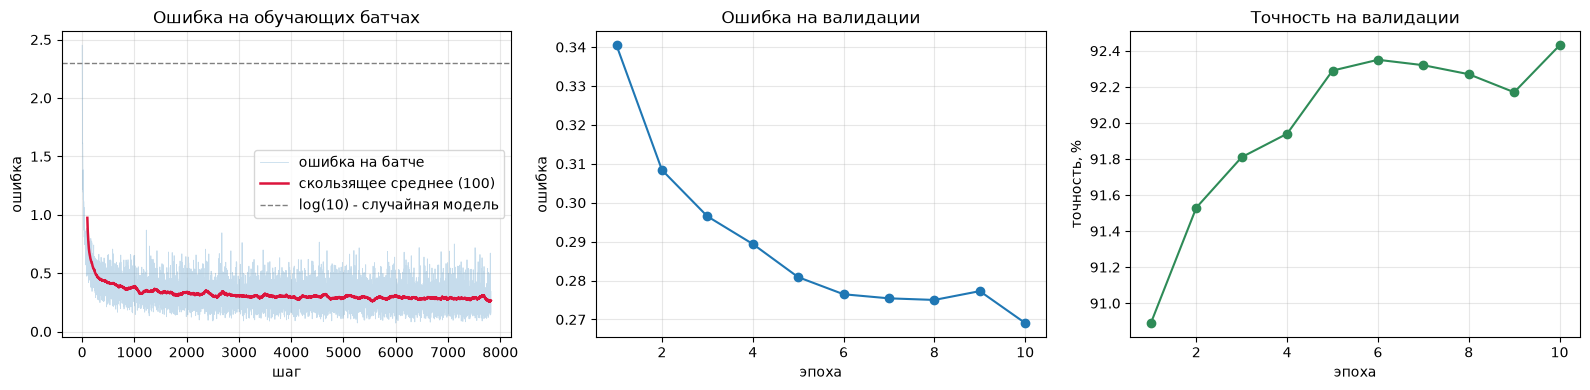

итог: ошибка 0.2691, точность 92.43%


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Ошибка на батчах очень шумная (каждый батч - всего 64 примера),
# поэтому рядом рисуем скользящее среднее
ax = axes[0]
ax.plot(hist_step, hist_loss, alpha=0.25, lw=0.6, label="ошибка на батче")
window = 100
smooth = torch.tensor(hist_loss).unfold(0, window, 1).mean(dim=1)
ax.plot(range(window - 1, len(hist_loss)), smooth, color="crimson", lw=1.8,
        label=f"скользящее среднее ({window})")
ax.axhline(math.log(10), ls="--", c="gray", lw=1, label="log(10) - случайная модель")
ax.set_xlabel("шаг"); ax.set_ylabel("ошибка")
ax.set_title("Ошибка на обучающих батчах"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(hist_epoch, hist_valid_loss, "o-")
ax.set_xlabel("эпоха"); ax.set_ylabel("ошибка")
ax.set_title("Ошибка на валидации"); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(hist_epoch, [a * 100 for a in hist_valid_acc], "o-", color="seagreen")
ax.set_xlabel("эпоха"); ax.set_ylabel("точность, %")
ax.set_title("Точность на валидации"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

final_loss, final_acc = evaluate(weights, bias, x_valid, y_valid)
print(f"итог: ошибка {final_loss:.4f}, точность {final_acc * 100:.2f}%")

Точность на валидации немного колеблется от эпохи к эпохе - это нормальный
шум SGD, а не ошибка. Ошибка на обучающих батчах при этом монотонно падает.

### Матрица ошибок

Итоговый процент скрывает структуру ошибок. Матрица ошибок показывает,
**какие** цифры модель путает: в ячейке $[i, j]$ стоит, сколько раз истинный
класс $i$ был предсказан как $j$. На диагонали - правильные ответы.

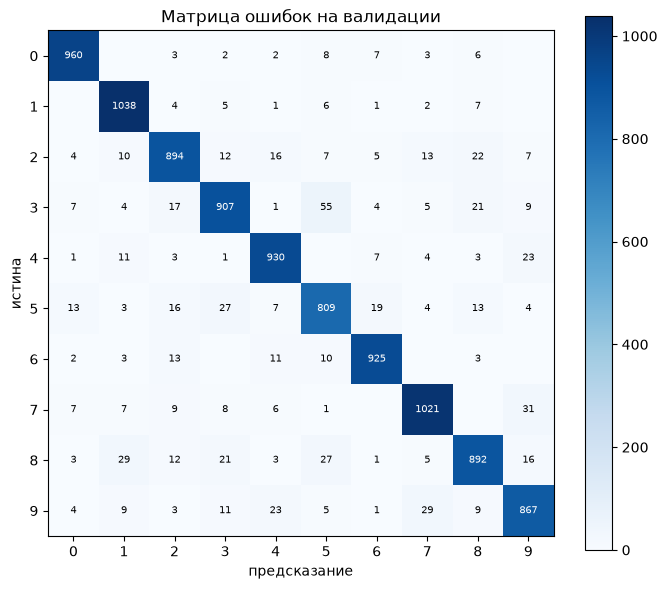

чаще всего модель путает:
  истинное 3 предсказано как 5: 55 раз
  истинное 7 предсказано как 9: 31 раз
  истинное 8 предсказано как 1: 29 раз
  истинное 9 предсказано как 7: 29 раз
  истинное 8 предсказано как 5: 27 раз
  истинное 5 предсказано как 3: 27 раз
  истинное 4 предсказано как 9: 23 раз
  истинное 9 предсказано как 4: 23 раз

точность по классам:
  0:  96.9%
  1:  97.6%
  2:  90.3%
  3:  88.1%
  4:  94.6%
  5:  88.4%
  6:  95.7%
  7:  93.7%
  8:  88.4%
  9:  90.2%


In [18]:
with torch.no_grad():
    preds_valid = torch.argmax(x_valid @ weights + bias, dim=1)

cm = torch.zeros(10, 10, dtype=torch.int64)
for t, p_ in zip(y_valid.tolist(), preds_valid.tolist()):
    cm[t, p_] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("предсказание"); ax.set_ylabel("истина")
ax.set_title("Матрица ошибок на валидации")
for i in range(10):
    for j in range(10):
        v = cm[i, j].item()
        if v:
            ax.text(j, i, v, ha="center", va="center", fontsize=7,
                    color="white" if v > cm.max() / 2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()

# Топ путаниц: обнулим диагональ и возьмем максимумы
off = cm.clone()
off.fill_diagonal_(0)
flat = off.flatten()
top = torch.topk(flat, 8)
print("чаще всего модель путает:")
for value, pos in zip(top.values.tolist(), top.indices.tolist()):
    print(f"  истинное {pos // 10} предсказано как {pos % 10}: {value} раз")

# Точность по каждому классу
print("\nточность по классам:")
for k in range(10):
    acc_k = cm[k, k].item() / cm[k].sum().item() * 100
    print(f"  {k}: {acc_k:5.1f}%")

### Чему научились веса

У линейной модели веса интерпретируются напрямую. Столбец $W[:, k]$ - это
784 числа, то есть картинка 28x28. Логит
$z_k = \sum_i x_i W_{ik}$ - скалярное произведение картинки и этого шаблона,
то есть мера их похожести.

Красное - положительный вес (пиксель здесь говорит "это класс $k$"),
синее - отрицательный (пиксель здесь говорит "это НЕ класс $k$").

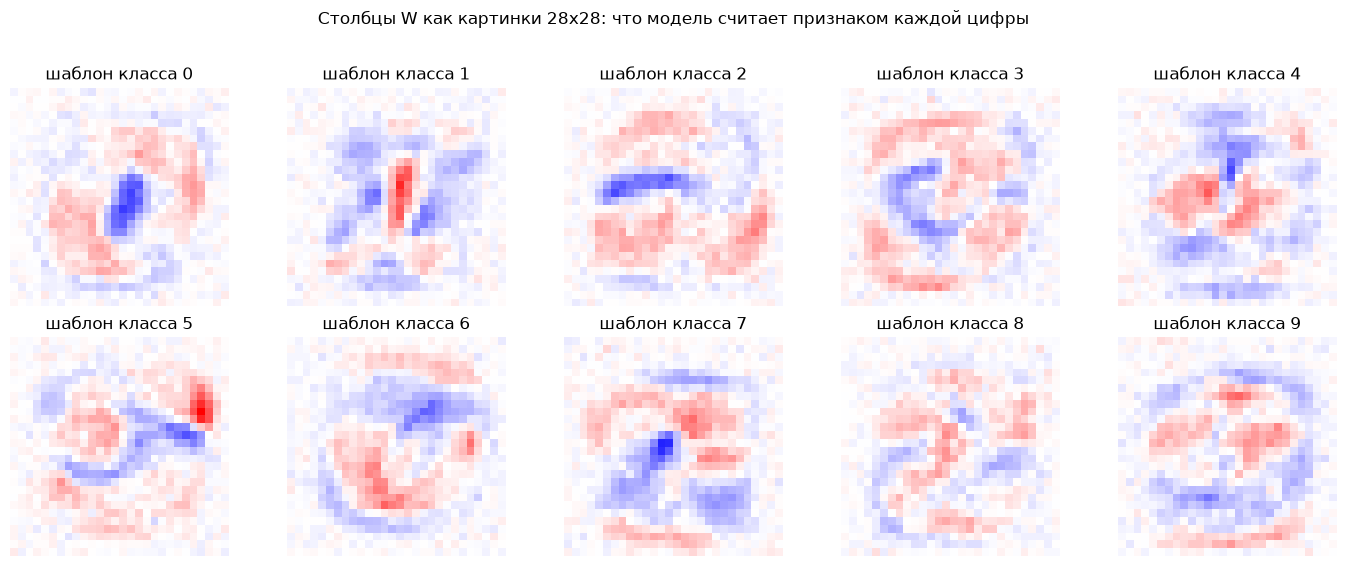

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(14, 5.5))
w_img = weights.detach()
limit = w_img.abs().max()

for k, ax in enumerate(axes.ravel()):
    ax.imshow(w_img[:, k].reshape(28, 28), cmap="bwr", vmin=-limit, vmax=limit)
    ax.set_title(f"шаблон класса {k}")
    ax.axis("off")

fig.suptitle("Столбцы W как картинки 28x28: что модель считает признаком каждой цифры",
             y=1.02)
plt.tight_layout()
plt.show()

В шаблоне нуля хорошо видно красное кольцо с синим центром: "по краю чернила
есть, в середине нет". В шаблоне единицы - красная вертикальная полоса
посередине и синие области по бокам.

### Примеры ошибок

ошибок на валидации: 757 из 10000


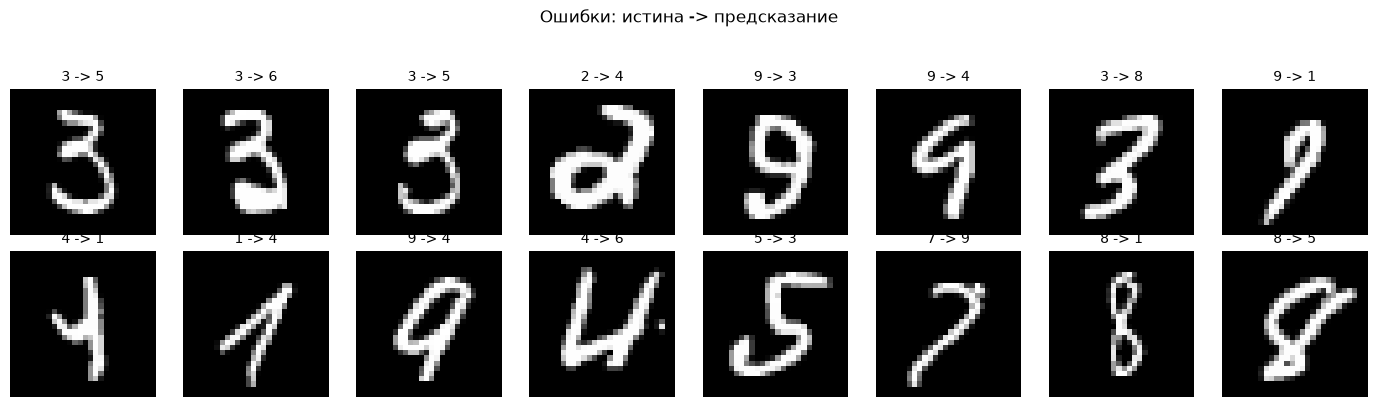

In [20]:
wrong = (preds_valid != y_valid).nonzero().flatten()
print(f"ошибок на валидации: {len(wrong)} из {len(y_valid)}")

fig, axes = plt.subplots(2, 8, figsize=(14, 3.8))
for ax, idx in zip(axes.ravel(), wrong[:16].tolist()):
    ax.imshow(x_valid[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"{y_valid[idx].item()} -> {preds_valid[idx].item()}", fontsize=10)
    ax.axis("off")
fig.suptitle("Ошибки: истина -> предсказание", y=1.06)
plt.tight_layout()
plt.show()

---
## 8. Где потолок линейной модели

Около 92% и выше не идет, сколько ни учить. Причина принципиальная.

Линейная модель для каждого класса держит **один** шаблон и считает похожесть
на него. Граница между любыми двумя классами у нее - гиперплоскость. Но
цифра "7" бывает с перекладиной и без, "1" бывает вертикальной и наклонной,
"4" бывает замкнутой и открытой. Один усредненный шаблон покрыть все эти
варианты не может: усреднение по вариантам дает размытое пятно, которое
плохо похоже на каждый из них.

Это свойство модели, а не нехватка данных или шагов обучения.

**Что делать.** Нужна модель, которая умеет строить несколько промежуточных
признаков и уже их комбинировать. Ровно это дает скрытый слой - и этим
занят ноутбук `03_mlp_manual.ipynb`, где та же задача решается с точностью
около 97%.

---
## Итоги ноутбука 02

**Разобранная математика:**

1. $p = \mathrm{softmax}(z)$, вычитание максимума обязательно для устойчивости;
2. $L = -\frac{1}{B}\sum_n \log p_{n,y_n}$ - перекрестная энтропия;
3. $\dfrac{\partial L}{\partial z} = \dfrac{\mathrm{softmax}(z) - Y}{B}$ - главная формула;
4. $\dfrac{\partial L}{\partial W} = x^\top G$, $\quad \dfrac{\partial L}{\partial b} = \mathrm{sum}(G, 0)$, $\quad \dfrac{\partial L}{\partial x} = G W^\top$;
5. шаг SGD: $W \leftarrow W - \eta \,\partial L/\partial W$.

**Приемы, которые стоит унести с собой:**

* прикидка стартовой ошибки: $\log(\text{число классов})$;
* контроль порядка множителей в backward по формам тензоров;
* тройная проверка градиента: аналитика, численная разность, autograd;
* матрица ошибок вместо одного процента точности.

**Полученный результат:** около 92.4% на валидации, 7850 параметров.